 # Underwater Image Denoising Demo

This notebook applies a **multi-stage denoising pipeline** to a single image.

Pipeline (in order):

1. Gaussian smoothing – remove high-frequency sensor noise.  
2. Median filtering – remove salt-and-pepper / particle speckle.  
3. Bilateral filtering (optional) – smooth homogeneous water regions while preserving edges.  
4. Laplacian high-boost sharpening – restore edge sharpness after smoothing.

Edit the `INPUT_IMAGE` and `OUTPUT_IMAGE` paths in the cell below, then run all cells.


In [1]:
# If you don't have these installed yet, run in a terminal:
# pip install opencv-python numpy matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_image(img, title=None, figsize=(6, 5)):
    """Utility to display BGR image with matplotlib."""
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


In [2]:
# ---- Denoising functions (Gaussian -> Median -> Bilateral -> Sharpen) ----

def gaussian_smooth(img, ksize=5, sigma=1.5):
    """Initial smoothing to remove high-frequency sensor noise."""
    ksize = int(ksize) | 1  # make sure it's odd
    return cv2.GaussianBlur(img, (ksize, ksize), sigmaX=sigma, sigmaY=sigma)

def median_filter(img, ksize=3):
    """Remove salt-and-pepper style particle noise while preserving edges."""
    ksize = int(ksize) | 1
    return cv2.medianBlur(img, ksize)

def add_salt_pepper_noise(img, amount=0.02, salt_vs_pepper=0.5, per_channel=False, seed=None):
    """Add random salt-and-pepper noise to an image.
    """
    if amount <= 0:
        return img.copy()

    amount = float(np.clip(amount, 0.0, 1.0))
    salt_vs_pepper = float(np.clip(salt_vs_pepper, 0.0, 1.0))

    h, w = img.shape[:2]
    total_pixels = h * w
    n_salt = int(round(total_pixels * amount * salt_vs_pepper))
    n_pepper = int(round(total_pixels * amount * (1.0 - salt_vs_pepper)))

    rng = np.random.default_rng(seed)
    noisy = img.copy()

    def _apply(coords, value, channel=None):
        if img.ndim == 2:
            noisy[coords[0], coords[1]] = value
        elif channel is None:
            noisy[coords[0], coords[1], :] = value
        else:
            noisy[coords[0], coords[1], channel] = value

    if per_channel and img.ndim == 3:
        for c in range(img.shape[2]):
            salt_coords = (
                rng.integers(0, h, n_salt, endpoint=False),
                rng.integers(0, w, n_salt, endpoint=False),
            )
            pepper_coords = (
                rng.integers(0, h, n_pepper, endpoint=False),
                rng.integers(0, w, n_pepper, endpoint=False),
            )
            _apply(salt_coords, 255, channel=c)
            _apply(pepper_coords, 0, channel=c)
    else:
        salt_coords = (
            rng.integers(0, h, n_salt, endpoint=False),
            rng.integers(0, w, n_salt, endpoint=False),
        )
        pepper_coords = (
            rng.integers(0, h, n_pepper, endpoint=False),
            rng.integers(0, w, n_pepper, endpoint=False),
        )
        _apply(salt_coords, 255)
        _apply(pepper_coords, 0)

    return noisy

def add_gaussian_noise(img, mean=0.0, std=10.0, clip_min=0, clip_max=255, seed=None):
    """Add zero-mean Gaussian noise and clip to valid range.
    """
    if std <= 0:
        return img.copy()

    rng = np.random.default_rng(seed)
    noise = rng.normal(loc=mean, scale=std, size=img.shape).astype(np.float32)

    f = img.astype(np.float32) + noise
    f = np.clip(f, clip_min, clip_max)
    return f.astype(img.dtype, copy=False)

def bilateral_filter_optional(img, d=0, sigma_color=25, sigma_space=None):
    """
    Edge-preserving smoothing.
    If d <= 0, returns img unchanged (i.e., skip this step).
    """
    if d is None or d <= 0:
        return img
    if sigma_space is None:
        sigma_space = max(10, d * 2)
    return cv2.bilateralFilter(img, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)

def laplacian_highboost(img, strength=0.3):
    """Recover edge sharpness after smoothing by subtracting scaled Laplacian."""
    if strength <= 0:
        return img
    f = img.astype(np.float32)
    lap = cv2.Laplacian(f, ddepth=cv2.CV_32F, ksize=3)
    out = f - strength * lap
    return np.clip(out, 0, 255).astype(np.uint8)

def unsharp_mask(img, amount=0.5, radius=3, threshold=0):
    """
    Apply Unsharp Mask (USM) sharpening.
    """
    radius = int(radius) | 1
    blurred = cv2.GaussianBlur(img, (radius, radius), 0)
    mask = cv2.subtract(img, blurred)
    if threshold > 0:
        low_contrast_mask = np.abs(mask) < threshold
        mask[low_contrast_mask] = 0
    sharpened = cv2.addWeighted(img, 1.0, mask, amount, 0)

    return sharpened
 
def remove_big_spots(img_bgr, thresh=220, k=5):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, thresh, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    inpainted = cv2.inpaint(img_bgr, mask_clean, 3, cv2.INPAINT_TELEA)
    return inpainted

def image_entropy(img_bgr):
    """
    Compute entropy of an image. Converts to uint8 grayscale safely.
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = gray.astype(np.uint8)

    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    hist = hist.ravel()

    p = hist / (hist.sum() + 1e-12)
    p = p[p > 0]

    return float(-np.sum(p * np.log2(p)))


In [3]:
INPUT_IMAGE = "../data/RUOD/RUOD_pic/test/001258.jpg"
OUTPUT_IMAGE = "output_denoised.jpg"

print("Input image path: ", INPUT_IMAGE)
print("Output image path:", OUTPUT_IMAGE)

Input image path:  ../data/RUOD/RUOD_pic/test/001258.jpg
Output image path: output_denoised.jpg


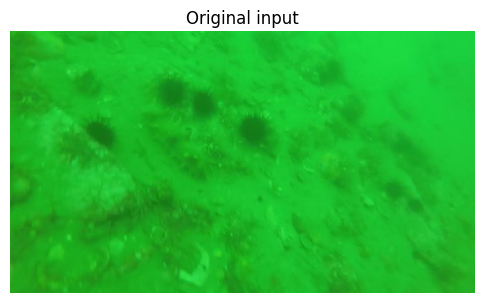

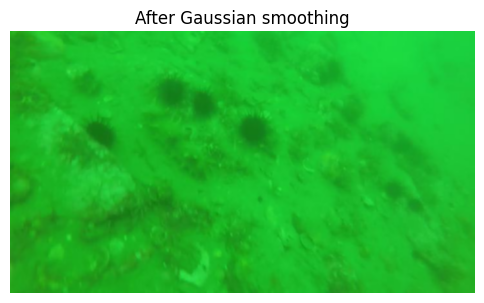

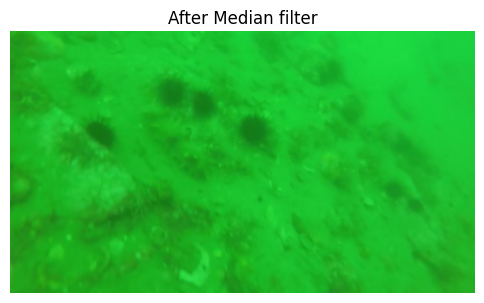

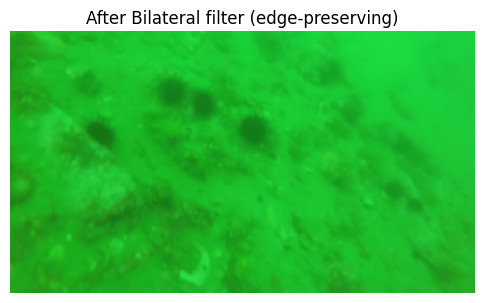

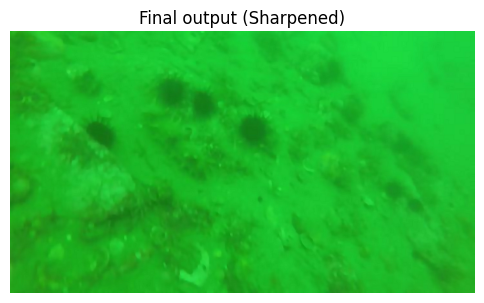

Saved denoised image to: output_denoised.jpg


In [18]:
# 1. Load
img = cv2.imread(INPUT_IMAGE, cv2.IMREAD_COLOR)
if img is None:
    raise FileNotFoundError(f"Could not read image at: {INPUT_IMAGE}")

show_image(img, "Original input")

# # add gaussian noise
# noisy = add_gaussian_noise(img, mean=0.0, std=15.0, seed=42)
# show_image(img, "With Gaussian noise")
# cv2.imwrite("after_gaussian_noise.jpg", img)

# add salt and pepper noise
# img = add_salt_pepper_noise(img, amount=0.02, salt_vs_pepper=0.5, per_channel=False, seed=None)
# show_image(img, "After salt and pepper noise")
# cv2.imwrite("after_salt_pepper.jpg", img)

# remove big spots if any
# img = remove_big_spots(img, thresh=200, k=5)

# 2. Gaussian smoothing
g = gaussian_smooth(img, ksize=3, sigma=1.5)
show_image(g, "After Gaussian smoothing")
cv2.imwrite("after_gaussian.jpg", g)

# 3. Median filtering
m = median_filter(g, ksize=3)
show_image(m, "After Median filter")
cv2.imwrite("after_median.jpg", m)

# 4. Bilateral (optional) - set d to 0 to skip
b = bilateral_filter_optional(m, d=5, sigma_color=25)
show_image(b, "After Bilateral filter (edge-preserving)")
cv2.imwrite("after_bilateral.jpg", b)

# 5. Sharpen
out = laplacian_highboost(b, strength=0.3)
show_image(out, "Final output (Sharpened)")
# out = unsharp_mask(b, amount=0.5, radius=3, threshold=0)
# show_image(out, "Final output (Sharpened)")

# 6. Save
cv2.imwrite(OUTPUT_IMAGE, out)
print("Saved denoised image to:", OUTPUT_IMAGE)


In [19]:
entropies = {
    "Original": image_entropy(img),
    # "Noisy": image_entropy(noisy),
    "Gaussian": image_entropy(g),
    "Median":   image_entropy(m),
    "Bilateral": image_entropy(b),
    "Sharpened": image_entropy(out),
}

for name, H in entropies.items():
    print(f"{name} entropy: {H:.3f} bits")

Original entropy: 5.616 bits
Gaussian entropy: 5.603 bits
Median entropy: 5.598 bits
Bilateral entropy: 5.589 bits
Sharpened entropy: 5.624 bits


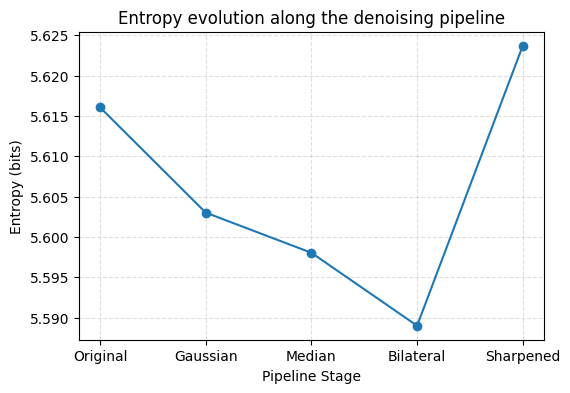

In [20]:
names = list(entropies.keys())
values = [entropies[k] for k in names]

plt.figure(figsize=(6, 4))
plt.plot(names, values, marker="o")
plt.xlabel("Pipeline Stage")
plt.ylabel("Entropy (bits)")
plt.title("Entropy evolution along the denoising pipeline")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


In [15]:
import sys, pathlib

# point this to your repo root
repo_root = pathlib.Path("../")
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from utils import quality_metrics  # or any module inside utils

In [16]:
from utils.quality_metrics import uiqm, uciqe, contrast_gain

def compute_quality_metrics(orig_img_bgr, enhanced_img_bgr):
    """
    Compute UIQM, UCIQE, and contrast gain for an image.
    Expects BGR inputs; converts to RGB internally for the metrics.
    """
    rgb_orig = cv2.cvtColor(orig_img_bgr, cv2.COLOR_BGR2RGB)
    rgb_enhanced = cv2.cvtColor(enhanced_img_bgr, cv2.COLOR_BGR2RGB)

    uiqm_val = uiqm(rgb_enhanced)
    uciqe_val = uciqe(rgb_enhanced)
    con_gain = contrast_gain(rgb_orig, rgb_enhanced)
    return uiqm_val, uciqe_val, con_gain



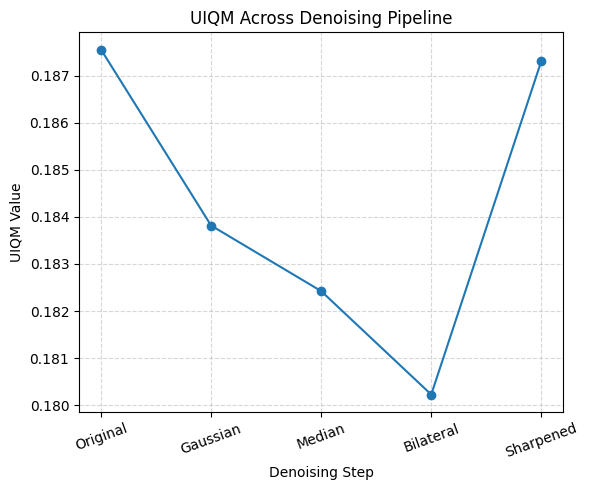

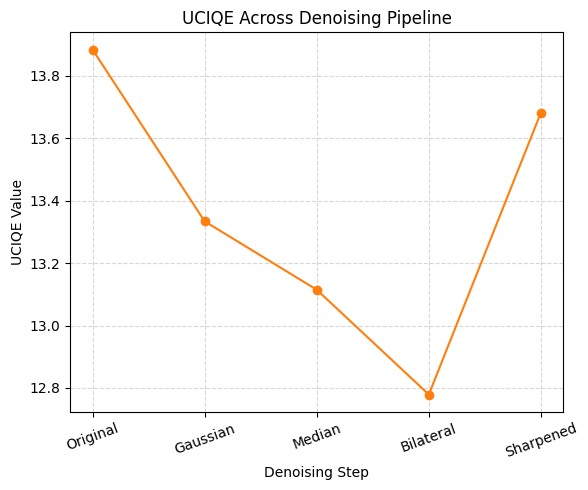

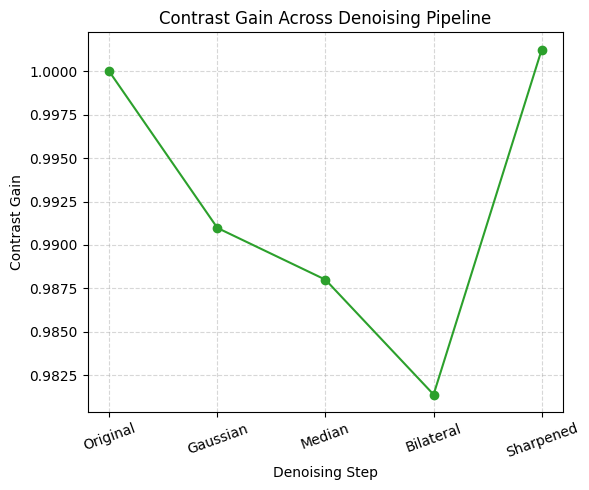

In [21]:
# Compute quality metrics for each step in the pipeline
metrics = {
    "Original": compute_quality_metrics(img, img),
    "Gaussian": compute_quality_metrics(img, g),
    "Median":   compute_quality_metrics(img, m),
    "Bilateral": compute_quality_metrics(img, b),
    "Sharpened": compute_quality_metrics(img, out),
}

import numpy as np
import matplotlib.pyplot as plt

metric_names = ["UIQM", "UCIQE", "Contrast Gain"]

# Organize the metrics per method
methods = list(metrics.keys())
uiqm_vals = [metrics[k][0] for k in methods]
uciqe_vals = [metrics[k][1] for k in methods]
contrast_gain_vals = [metrics[k][2] for k in methods]

x = np.arange(len(methods))

# Plot each metric in a separate figure
plt.figure(figsize=(6, 5))
plt.plot(x, uiqm_vals, marker='o', color='tab:blue')
plt.xticks(x, methods, rotation=20)
plt.xlabel("Denoising Step")
plt.ylabel("UIQM Value")
plt.title("UIQM Across Denoising Pipeline")
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(x, uciqe_vals, marker='o', color='tab:orange')
plt.xticks(x, methods, rotation=20)
plt.xlabel("Denoising Step")
plt.ylabel("UCIQE Value")
plt.title("UCIQE Across Denoising Pipeline")
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(x, contrast_gain_vals, marker='o', color='tab:green')
plt.xticks(x, methods, rotation=20)
plt.xlabel("Denoising Step")
plt.ylabel("Contrast Gain")
plt.title("Contrast Gain Across Denoising Pipeline")
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [10]:
# print the original and final metric
print(f"UIQM (original):   {metrics['Original'][0]:.4f}")
print(f"UCIQE (original):   {metrics['Original'][1]:.4f}")
print(f"Contrast gain:    {metrics['Original'][2]:.4f} (original vs original)")

print(f"UIQM (output):   {metrics['Sharpened'][0]:.4f}")
print(f"UCIQE (output):   {metrics['Sharpened'][1]:.4f}")
print(f"Contrast gain:    {metrics['Sharpened'][2]:.4f} (output vs original)")

UIQM (original):   0.1876
UCIQE (original):   13.8839
Contrast gain:    1.0000 (original vs original)
UIQM (output):   0.1844
UCIQE (output):   13.3451
Contrast gain:    0.9930 (output vs original)


In [11]:
import pathlib
from utils.denoise_pipeline import PipelineConfig, process_directory, summarize_metrics

input_dir = pathlib.Path("../data/RUOD/RUOD_pic/test")
# output_dir = pathlib.Path("../results/denoised_cuttlefish")

cfg = PipelineConfig(
    gaussian_ksize=5,
    gaussian_sigma=1.5,
    median_ksize=3,
    bilateral_d=7,
    sharpen_strength=0.3,
    remove_spots=False,
)

results = process_directory(input_dir, None, cfg, compute_metrics_flag=True, save_output=False, max_images=100)
print(summarize_metrics(results))

[OK] ../data/RUOD/RUOD_pic/test/000001.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000004.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000005.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000012.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000020.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000035.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000037.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000039.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000042.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000043.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000045.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000046.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000048.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000050.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000054.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000061.jpg (metrics only)
[OK] ../data/RUOD/RUOD_pic/test/000072.jpg (metrics only)
[OK] ../data/R